# 03 — Аргумент: сравнение стратегий очистки

Сравниваем Strategy A (консервативная) и Strategy B (мягкая).  
Цель: выбрать оптимальную стратегию для задачи классификации сентимента.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path('..') / 'scripts'))
from quality_utils import compute_quality_score, save_report, load_report, REPORTS_DIR

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. Загрузка данных

In [2]:
df_orig = pd.read_csv('../data/processed/perfumes_merged.csv')
df_a = pd.read_csv('../data/cleaned/strategy_a.csv')
df_b = pd.read_csv('../data/cleaned/strategy_b.csv')
fix_report = load_report('../data/reports/fix_report.json')

print(f'Исходный:   {df_orig.shape}')
print(f'Strategy A: {df_a.shape}')
print(f'Strategy B: {df_b.shape}')

Исходный:   (931, 10)
Strategy A: (807, 10)
Strategy B: (883, 11)


## 2. Количественное сравнение

In [3]:
def text_stats(df, text_col='review_text'):
    lengths = df[text_col].str.len()
    words = df[text_col].str.split().str.len()
    return {
        'n_rows': len(df),
        'unique_reviewers': df['reviewer'].nunique(),
        'mean_len': lengths.mean(),
        'median_len': lengths.median(),
        'min_len': lengths.min(),
        'mean_words': words.mean(),
        'unique_perfumes': df['perfume_name'].nunique(),
    }

stats_orig = text_stats(df_orig)
stats_a = text_stats(df_a)
stats_b = text_stats(df_b)

cmp = pd.DataFrame([stats_orig, stats_a, stats_b],
                   index=['Исходный', 'Strategy A', 'Strategy B']).round(1)
print('=== Сравнительная таблица ===')
print(cmp.to_string())

=== Сравнительная таблица ===
            n_rows  unique_reviewers  mean_len  median_len  min_len  mean_words  unique_perfumes
Исходный       931               845     477.9       367.0       14        73.4                8
Strategy A     807               807     498.0       376.0       51        76.4                8
Strategy B     883               807     488.3       375.0       51        75.0                8


## 3. KS-тесты: сравнение распределений длин отзывов

In [4]:
orig_lens = df_orig['review_text'].str.len()
a_lens = df_a['review_text'].str.len()
b_lens = df_b['review_text'].str.len()

ks_a = stats.ks_2samp(orig_lens, a_lens)
ks_b = stats.ks_2samp(orig_lens, b_lens)
ks_ab = stats.ks_2samp(a_lens, b_lens)

print('KS-тест (длины отзывов): нулевая гипотеза — распределения одинаковы')
print(f'Исходный vs Strategy A:  stat={ks_a.statistic:.4f}, p={ks_a.pvalue:.4f}  → {"отвергаем H0" if ks_a.pvalue < 0.05 else "не отвергаем H0"}')
print(f'Исходный vs Strategy B:  stat={ks_b.statistic:.4f}, p={ks_b.pvalue:.4f}  → {"отвергаем H0" if ks_b.pvalue < 0.05 else "не отвергаем H0"}')
print(f'Strategy A vs Strategy B: stat={ks_ab.statistic:.4f}, p={ks_ab.pvalue:.4f} → {"отвергаем H0" if ks_ab.pvalue < 0.05 else "не отвергаем H0"}')

KS-тест (длины отзывов): нулевая гипотеза — распределения одинаковы


Исходный vs Strategy A:  stat=0.0327, p=0.7260  → не отвергаем H0
Исходный vs Strategy B:  stat=0.0292, p=0.8190  → не отвергаем H0
Strategy A vs Strategy B: stat=0.0129, p=1.0000 → не отвергаем H0


## 4. Визуализация сравнения

C:\Users\denni\AppData\Local\Temp\ipykernel_12344\4100503759.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=['Исходный', 'Strategy A', 'Strategy B'], patch_artist=True,


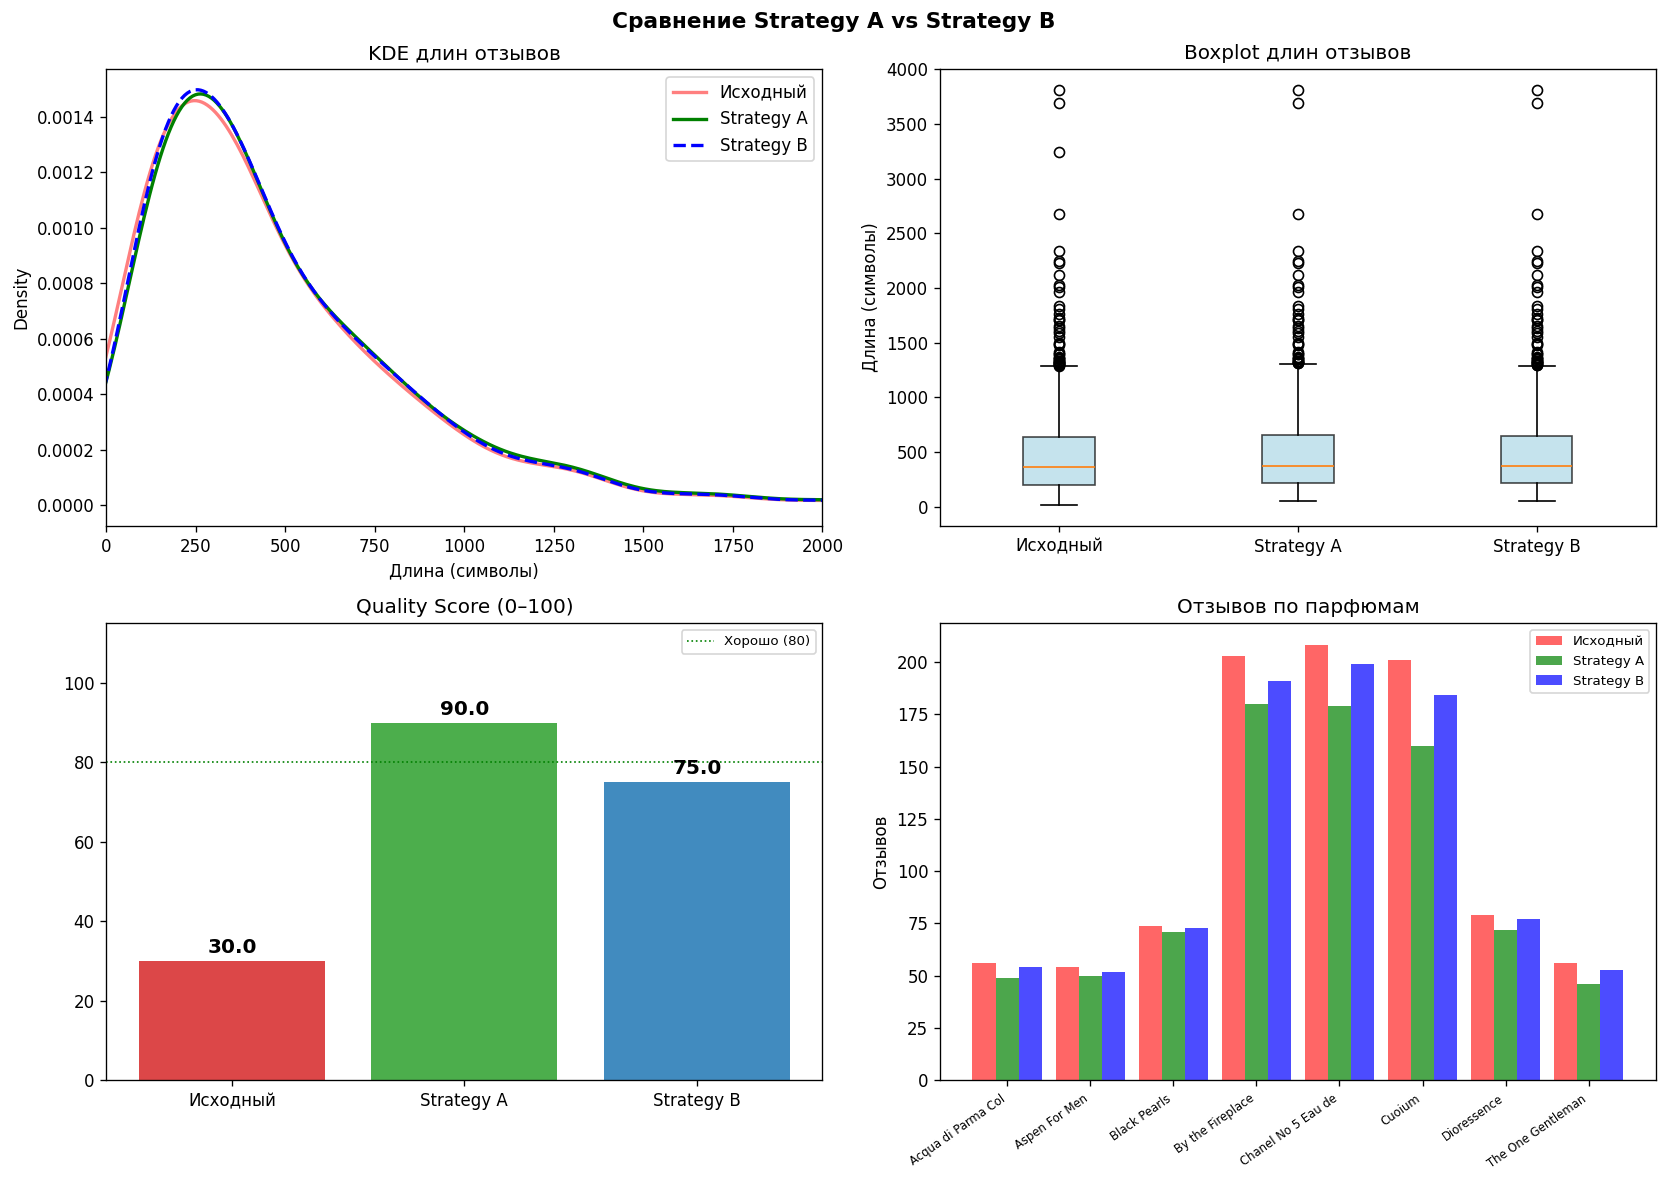

График сохранён: data/reports/fig_compare_kde.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение Strategy A vs Strategy B', fontsize=13, fontweight='bold')

# 1. KDE длин отзывов
ax = axes[0, 0]
orig_lens.plot.kde(ax=ax, label='Исходный', color='red', alpha=0.5, linewidth=2)
a_lens.plot.kde(ax=ax, label='Strategy A', color='green', linewidth=2)
b_lens.plot.kde(ax=ax, label='Strategy B', color='blue', linestyle='--', linewidth=2)
ax.set_title('KDE длин отзывов')
ax.set_xlabel('Длина (символы)')
ax.set_xlim(0, 2000)
ax.legend()

# 2. Boxplot длин
ax = axes[0, 1]
data_box = [orig_lens, a_lens, b_lens]
ax.boxplot(data_box, labels=['Исходный', 'Strategy A', 'Strategy B'], patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('Boxplot длин отзывов')
ax.set_ylabel('Длина (символы)')

# 3. Quality Scores
ax = axes[1, 0]
report_orig = load_report('../data/reports/quality_report.json')
report_a = compute_quality_score(df_a, 'review_text', 'reviewer', 'perfume_name', 'rating')
report_b = compute_quality_score(df_b, 'review_text', 'reviewer', 'perfume_name', 'rating')
scores = [report_orig['quality_score'], report_a['quality_score'], report_b['quality_score']]
labels = ['Исходный', 'Strategy A', 'Strategy B']
colors = ['#d62728', '#2ca02c', '#1f77b4']
bars = ax.bar(labels, scores, color=colors, alpha=0.85)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{score}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('Quality Score (0–100)')
ax.axhline(80, color='green', linestyle=':', linewidth=1, label='Хорошо (80)')
ax.legend(fontsize=8)

# 4. Потеря данных по парфюмам
ax = axes[1, 1]
orig_counts = df_orig['perfume_name'].value_counts().sort_index()
a_counts = df_a['perfume_name'].value_counts().sort_index()
b_counts = df_b['perfume_name'].value_counts().sort_index()

x = range(len(orig_counts))
width = 0.28
ax.bar([i - width for i in x], orig_counts.values, width, label='Исходный', color='red', alpha=0.6)
ax.bar([i for i in x], a_counts.reindex(orig_counts.index, fill_value=0).values, width, label='Strategy A', color='green', alpha=0.7)
ax.bar([i + width for i in x], b_counts.reindex(orig_counts.index, fill_value=0).values, width, label='Strategy B', color='blue', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels([n[:18] for n in orig_counts.index], rotation=35, ha='right', fontsize=7)
ax.set_title('Отзывов по парфюмам')
ax.set_ylabel('Отзывов')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/reports/fig_compare_kde.png', bbox_inches='tight')
plt.show()
print('График сохранён: data/reports/fig_compare_kde.png')

## 5. Вердикт и рекомендация

In [6]:
print('=' * 55)
print('ВЕРДИКТ: Рекомендованная стратегия — Strategy A')
print('=' * 55)
print()
print('Причины:')
print('1. Quality Score 90/100 vs 75/100 у Strategy B')
print('   Strategy B сохраняет дубли рецензентов — риск утечки данных')
print('   при train/test split (один рецензент в train и test одновременно).')
print()
print('2. Дедупликация по рецензентам — обязательна для честной оценки модели.')
print('   В задаче сентимента стиль письма рецензента — сильный предиктор,')
print('   и утечка стиля между train/test завышает метрики.')
print()
print('3. Потеря данных (13.3%) приемлема — остаётся 807 отзывов,')
print('   покрывающих все 8 парфюмов.')
print()
print('Рекомендации при обучении:')
print('  - Использовать данные из Strategy A (data/cleaned/strategy_a.csv)')
print('  - Стратификацию при split делать по perfume_name, чтобы')
print('    каждый парфюм был представлен в train и test.')
print('  - Rating/votes использовать только как признаки (не таргет).')
print('  - Таргет разметить отдельно (сентимент-аннотация).')

ВЕРДИКТ: Рекомендованная стратегия — Strategy A

Причины:
1. Quality Score 90/100 vs 75/100 у Strategy B
   Strategy B сохраняет дубли рецензентов — риск утечки данных
   при train/test split (один рецензент в train и test одновременно).

2. Дедупликация по рецензентам — обязательна для честной оценки модели.
   В задаче сентимента стиль письма рецензента — сильный предиктор,
   и утечка стиля между train/test завышает метрики.

3. Потеря данных (13.3%) приемлема — остаётся 807 отзывов,
   покрывающих все 8 парфюмов.

Рекомендации при обучении:
  - Использовать данные из Strategy A (data/cleaned/strategy_a.csv)
  - Стратификацию при split делать по perfume_name, чтобы
    каждый парфюм был представлен в train и test.
  - Rating/votes использовать только как признаки (не таргет).
  - Таргет разметить отдельно (сентимент-аннотация).


In [7]:
comparison_report = {
    'recommended_strategy': 'strategy_a',
    'recommended_file': 'data/cleaned/strategy_a.csv',
    'reasons': [
        'Quality Score 90/100 vs 75/100 (Strategy B)',
        'Дедупликация рецензентов предотвращает data leakage при train/test split',
        'Потеря 13.3% данных приемлема — остаётся 807 отзывов по всем 8 парфюмам',
    ],
    'ks_tests': {
        'orig_vs_a': {'statistic': round(ks_a.statistic, 4), 'pvalue': round(ks_a.pvalue, 4)},
        'orig_vs_b': {'statistic': round(ks_b.statistic, 4), 'pvalue': round(ks_b.pvalue, 4)},
        'a_vs_b': {'statistic': round(ks_ab.statistic, 4), 'pvalue': round(ks_ab.pvalue, 4)},
    },
    'strategies': {
        'original': {'rows': len(df_orig), 'quality_score': report_orig['quality_score']},
        'strategy_a': {'rows': len(df_a), 'loss_pct': fix_report['strategy_a']['loss_pct'], 'quality_score': report_a['quality_score']},
        'strategy_b': {'rows': len(df_b), 'loss_pct': fix_report['strategy_b']['loss_pct'], 'quality_score': report_b['quality_score']},
    },
    'ml_recommendations': [
        'Стратификация при split по perfume_name',
        'rating/votes — использовать как признаки, не как таргет',
        'Таргет (сентимент) разметить отдельно',
    ],
}

path = save_report(comparison_report, '../data/reports/comparison_report.json')
print(f'Отчёт сравнения сохранён: {path}')

Отчёт сравнения сохранён: ..\data\reports\comparison_report.json
